In [1]:
#MODULE1

import collections
import os

def parse_fastq(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"'{file_path}' faylı tapılmadı.")
        
    records = []
    with open(file_path, 'r', encoding='utf-8') as handle:
        while True:
            header = handle.readline().strip()
            if not header:
                break
            seq = handle.readline().strip()
            plus = handle.readline().strip()
            qual = handle.readline().strip()
            records.append({
                'header': header,
                'seq': seq,
                'plus': plus,
                'qual': qual
            })
    return records

def calculate_qc_metrics(records):
    total_reads = len(records)
    total_bases = 0
    q20_bases = 0
    q30_bases = 0

    for rec in records:
        phred_scores = [ord(char) - 33 for char in rec['qual']]
        for q in phred_scores:
            total_bases += 1
            if q >= 20:
                q20_bases += 1
            if q >= 30:
                q30_bases += 1

    pct_q20 = (q20_bases / total_bases) * 100 if total_bases > 0 else 0.0
    pct_q30 = (q30_bases / total_bases) * 100 if total_bases > 0 else 0.0

    return {
        'total_reads': total_reads,
        'total_bases': total_bases,
        'pct_q20': pct_q20,
        'pct_q30': pct_q30
    }

In [6]:
#MODULE2



import os

def filter_and_trim_reads(records, min_q=20, min_length=50, max_n=2):
    filtered_records = []
    
    for rec in records:
        seq = rec['seq']
        qual = rec['qual']
        
        cut_index = len(qual)
        for i in range(len(qual) - 1, -1, -1):
            q_score = ord(qual[i]) - 33
            if q_score < min_q:
                cut_index = i
            else:
                break
                
        trimmed_seq = seq[:cut_index]
        trimmed_qual = qual[:cut_index]
        
        if trimmed_seq.count('N') > max_n:
            continue
            
        if len(trimmed_seq) < min_length:
            continue
            
        filtered_records.append({
            'header': rec['header'],
            'seq': trimmed_seq,
            'plus': rec['plus'],
            'qual': trimmed_qual
        })
        
    return filtered_records

def write_fastq(records, output_path):
    # Qovluq mövcud deyilsə, avtomatik yaradılır
    output_dir = os.path.dirname(output_path)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)
        
    with open(output_path, 'w', encoding='utf-8') as f:
        for rec in records:
            f.write(f"{rec['header']}\n{rec['seq']}\n{rec['plus']}\n{rec['qual']}\n")

In [7]:
#MODULE3

import base64
from io import BytesIO
import matplotlib.pyplot as plt

def generate_qc_report(records, metrics, output_path="output/qc_report.html"):
    if not records:
        print("Vizualizasiya üçün heç bir oxunuş tapılmadı!")
        return

    position_scores = collections.defaultdict(list)
    gc_percentages = []

    for rec in records:
        seq = rec['seq']
        qual = rec['qual']
        
        if len(seq) > 0:
            gc_pct = ((seq.count('G') + seq.count('C')) / len(seq)) * 100
            gc_percentages.append(gc_pct)
            
        for idx, char in enumerate(qual):
            position_scores[idx].append(ord(char) - 33)

    positions = sorted(position_scores.keys())
    mean_scores = [sum(position_scores[pos]) / len(position_scores[pos]) for pos in positions]

    # --- Qrafik 1: Per-Base Quality ---
    fig1, ax1 = plt.subplots(figsize=(9, 4))
    ax1.axhspan(28, 42, color="#d4edda", alpha=0.6)
    ax1.axhspan(20, 28, color="#fff3cd", alpha=0.6)
    ax1.axhspan(0, 20, color="#f8d7da", alpha=0.6)

    ax1.plot(positions, mean_scores, color="#007bff", marker='o', linewidth=2, label="Orta Phred Balı")
    ax1.set_title("Per-Base Sequence Quality", fontsize=12, fontweight='bold')
    ax1.set_xlabel("DNT Pozisiyası (bp)")
    ax1.set_ylabel("Phred Quality Score")
    ax1.set_ylim(0, 42)
    ax1.grid(True, linestyle="--", alpha=0.5)
    
    buf1 = BytesIO()
    fig1.savefig(buf1, format="png", bbox_inches='tight', dpi=150)
    img1_base64 = base64.b64encode(buf1.getvalue()).decode('utf-8')
    
    # Jupyter Notebook ekranında qrafiki dərhal göstərmək üçün:
    plt.show()
    plt.close(fig1)

    # --- Qrafik 2: GC Distribution ---
    fig2, ax2 = plt.subplots(figsize=(9, 4))
    ax2.hist(gc_percentages, bins=15, color="#28a745", edgecolor="black", alpha=0.7)
    ax2.set_title("GC Content Distribution", fontsize=12, fontweight='bold')
    ax2.set_xlabel("GC Faizi (%)")
    ax2.set_ylabel("Oxunuş Sayı")
    ax2.grid(True, linestyle="--", alpha=0.5)

    buf2 = BytesIO()
    fig2.savefig(buf2, format="png", bbox_inches='tight', dpi=150)
    img2_base64 = base64.b64encode(buf2.getvalue()).decode('utf-8')
    
    plt.show()
    plt.close(fig2)

    # HTML Faylının yaradılması
    html_content = f"""<!DOCTYPE html>
<html lang="az">
<head>
    <meta charset="UTF-8">
    <title>NEXAGEN - FastQ Quality Control Hesabatı</title>
    <style>
        body {{ font-family: Arial, sans-serif; background-color: #f4f6f9; padding: 20px; }}
        .container {{ max-width: 900px; margin: 0 auto; background: white; padding: 25px; border-radius: 8px; }}
        h1 {{ color: #1a2a3a; text-align: center; border-bottom: 2px solid #007bff; padding-bottom: 10px; }}
        .metrics-table {{ width: 100%; border-collapse: collapse; margin-bottom: 25px; }}
        .metrics-table th, .metrics-table td {{ border: 1px solid #dee2e6; padding: 10px; text-align: center; }}
        .metrics-table th {{ background-color: #007bff; color: white; }}
        .plot-container {{ text-align: center; margin-bottom: 25px; }}
        .plot-container img {{ max-width: 100%; border: 1px solid #ddd; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>NEXAGEN - FastQ Quality Control Hesabatı</h1>
        <h3>📊 Ümumi Keyfiyyət Metrikaları</h3>
        <table class="metrics-table">
            <thead>
                <tr>
                    <th>Ümumi Oxunuş (Reads)</th>
                    <th>Ümumi Baz (Bases)</th>
                    <th>Q20 Faizi (>90%)</th>
                    <th>Q30 Faizi (>85%)</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td>{metrics['total_reads']}</td>
                    <td>{metrics['total_bases']}</td>
                    <td><strong>{metrics['pct_q20']:.2f}%</strong></td>
                    <td><strong>{metrics['pct_q30']:.2f}%</strong></td>
                </tr>
            </tbody>
        </table>
        <div class="plot-container">
            <h3>Per-Base Sequence Quality</h3>
            <img src="data:image/png;base64,{img1_base64}">
        </div>
        <div class="plot-container">
            <h3>GC Content Distribution</h3>
            <img src="data:image/png;base64,{img2_base64}">
        </div>
    </div>
</body>
</html>"""

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(html_content)

In [8]:
#MODULE4

# Sınaq üçün nümunə sample.fastq faylı yaradırıq
sample_fastq_data = """@SRR12095148.1 1/1
AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGC
+
III#IIIFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF
@SRR12095148.2 1/1
AAGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCA
+
II#IIIIFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF
@SRR12095148.3 1/1
CTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGCC
+
I#IIIIFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF
@SRR12095148.4 1/1
GATCGAAGAGCACACGTCTGAACTCCAGTCACATCACGATCTCGTATGCCGTCTTCTGCTTGAAAAAAAA
+
!!""##$$%%&&''()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_
"""

with open("sample.fastq", "w", encoding="utf-8") as f:
    f.write(sample_fastq_data.strip())

print("✅ Test üçün 'sample.fastq' faylı yaradıldı.")

✅ Test üçün 'sample.fastq' faylı yaradıldı.


<>:4: SyntaxWarning: invalid escape sequence '\]'
<>:4: SyntaxWarning: invalid escape sequence '\]'
C:\Users\Acer\AppData\Local\Temp\ipykernel_6296\3612325424.py:4: SyntaxWarning: invalid escape sequence '\]'
  sample_fastq_data = """@SRR12095148.1 1/1


⏳ FASTQ faylı oxunur...
⏳ Filtrləmə və kəsilmə icra olunur...
✅ Təmizlənmiş fayl saxlanıldı: output\clean_reads.fastq
⏳ Metrikalar hesablanır və vizuallaşdırılır...


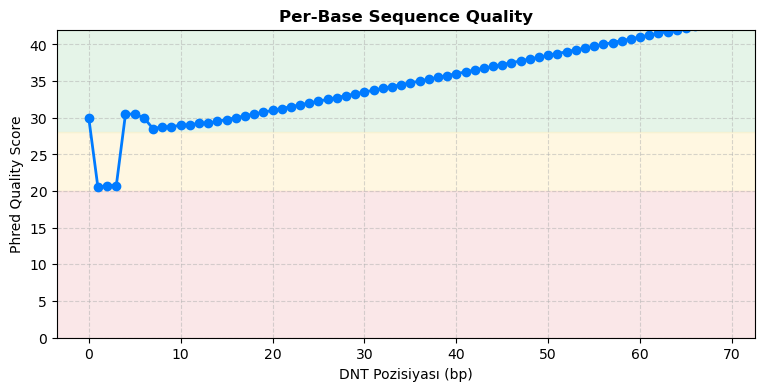

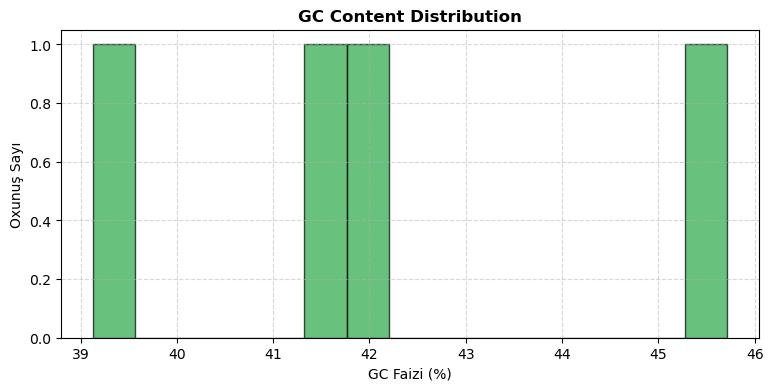


🎉 Uğurla tamamlandı! HTML hesabat: output\qc_report.html


In [9]:
import os

# Parametrlər
input_file = "sample.fastq"
output_dir = "output"
min_q = 20
min_length = 50
max_n = 2

# Output qovluğunu öncədən zəmanətli yaradırıq
os.makedirs(output_dir, exist_ok=True)

# Step 1: Parsing
print("⏳ FASTQ faylı oxunur...")
raw_records = parse_fastq(input_file)

# Step 2: Filtering & Trimming
print("⏳ Filtrləmə və kəsilmə icra olunur...")
clean_records = filter_and_trim_reads(raw_records, min_q=min_q, min_length=min_length, max_n=max_n)

clean_fastq_path = os.path.join(output_dir, "clean_reads.fastq")
write_fastq(clean_records, clean_fastq_path)
print(f"✅ Təmizlənmiş fayl saxlanıldı: {clean_fastq_path}")

# Step 3: Metrics & Report Generation
print("⏳ Metrikalar hesablanır və vizuallaşdırılır...")
metrics = calculate_qc_metrics(clean_records)

html_report_path = os.path.join(output_dir, "qc_report.html")
generate_qc_report(clean_records, metrics, html_report_path)

print(f"\n🎉 Uğurla tamamlandı! HTML hesabat: {html_report_path}")

In [ ]:
import os
import collections
import base64
from io import BytesIO
import tkinter as tk
from tkinter import filedialog, messagebox
import matplotlib.pyplot as plt

# --- 1. KÖMƏKÇİ FUNKSİYALAR ---

def parse_fastq(file_path):
    records = []
    with open(file_path, 'r', encoding='utf-8') as handle:
        while True:
            header = handle.readline().strip()
            if not header:
                break
            seq = handle.readline().strip()
            plus = handle.readline().strip()
            qual = handle.readline().strip()
            records.append({'header': header, 'seq': seq, 'plus': plus, 'qual': qual})
    return records

def filter_and_trim_reads(records, min_q=20, min_length=50, max_n=2):
    filtered_records = []
    for rec in records:
        seq, qual = rec['seq'], rec['qual']
        cut_index = len(qual)
        for i in range(len(qual) - 1, -1, -1):
            if (ord(qual[i]) - 33) < min_q:
                cut_index = i
            else:
                break
        trimmed_seq, trimmed_qual = seq[:cut_index], qual[:cut_index]
        if trimmed_seq.count('N') > max_n or len(trimmed_seq) < min_length:
            continue
        filtered_records.append({'header': rec['header'], 'seq': trimmed_seq, 'plus': rec['plus'], 'qual': trimmed_qual})
    return filtered_records

def calculate_qc_metrics(records):
    total_reads = len(records)
    total_bases, q20_bases, q30_bases = 0, 0, 0
    for rec in records:
        for char in rec['qual']:
            q = ord(char) - 33
            total_bases += 1
            if q >= 20: q20_bases += 1
            if q >= 30: q30_bases += 1
    return {
        'total_reads': total_reads,
        'total_bases': total_bases,
        'pct_q20': (q20_bases / total_bases) * 100 if total_bases > 0 else 0.0,
        'pct_q30': (q30_bases / total_bases) * 100 if total_bases > 0 else 0.0
    }

def generate_qc_report(records, metrics, output_path):
    position_scores = collections.defaultdict(list)
    gc_percentages = []

    for rec in records:
        seq, qual = rec['seq'], rec['qual']
        if len(seq) > 0:
            gc_percentages.append(((seq.count('G') + seq.count('C')) / len(seq)) * 100)
        for idx, char in enumerate(qual):
            position_scores[idx].append(ord(char) - 33)

    positions = sorted(position_scores.keys())
    mean_scores = [sum(position_scores[pos]) / len(position_scores[pos]) for pos in positions]

    # Qrafik 1
    fig1, ax1 = plt.subplots(figsize=(8, 3.5))
    ax1.axhspan(28, 42, color="#d4edda", alpha=0.6)
    ax1.axhspan(20, 28, color="#fff3cd", alpha=0.6)
    ax1.axhspan(0, 20, color="#f8d7da", alpha=0.6)
    ax1.plot(positions, mean_scores, color="#007bff", marker='o', linewidth=2)
    ax1.set_title("Per-Base Sequence Quality", fontweight='bold')
    ax1.set_xlabel("DNT Pozisiyası (bp)")
    ax1.set_ylabel("Phred Quality Score")
    ax1.set_ylim(0, 42)
    ax1.grid(True, linestyle="--", alpha=0.5)
    
    buf1 = BytesIO()
    fig1.savefig(buf1, format="png", bbox_inches='tight', dpi=120)
    img1_base64 = base64.b64encode(buf1.getvalue()).decode('utf-8')
    plt.close(fig1)

    # Qrafik 2
    fig2, ax2 = plt.subplots(figsize=(8, 3.5))
    ax2.hist(gc_percentages, bins=15, color="#28a745", edgecolor="black", alpha=0.7)
    ax2.set_title("GC Content Distribution", fontweight='bold')
    ax2.set_xlabel("GC Faizi (%)")
    ax2.set_ylabel("Oxunuş Sayı")
    ax2.grid(True, linestyle="--", alpha=0.5)

    buf2 = BytesIO()
    fig2.savefig(buf2, format="png", bbox_inches='tight', dpi=120)
    img2_base64 = base64.b64encode(buf2.getvalue()).decode('utf-8')
    plt.close(fig2)

    html_content = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>NEXAGEN QC Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; background-color: #f4f6f9; padding: 20px; }}
        .container {{ max-width: 800px; margin: 0 auto; background: white; padding: 20px; border-radius: 8px; }}
        h1 {{ color: #007bff; text-align: center; }}
        table {{ width: 100%; border-collapse: collapse; margin-bottom: 20px; }}
        th, td {{ border: 1px solid #ddd; padding: 10px; text-align: center; }}
        th {{ background-color: #007bff; color: white; }}
        .plot {{ text-align: center; margin-bottom: 20px; }}
        img {{ max-width: 100%; border: 1px solid #ccc; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>NEXAGEN - FastQ QC Hesabatı</h1>
        <table>
            <tr><th>Reads</th><th>Bases</th><th>Q20 (%)</th><th>Q30 (%)</th></tr>
            <tr><td>{metrics['total_reads']}</td><td>{metrics['total_bases']}</td><td>{metrics['pct_q20']:.2f}%</td><td>{metrics['pct_q30']:.2f}%</td></tr>
        </table>
        <div class="plot"><h3>Per-Base Quality</h3><img src="data:image/png;base64,{img1_base64}"></div>
        <div class="plot"><h3>GC Distribution</h3><img src="data:image/png;base64,{img2_base64}"></div>
    </div>
</body>
</html>"""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(html_content)

# --- 2. QRAFİK İSTİFADƏÇİ İNTERFEYSİ (GUI) ---

class NexagenQCApp:
    def __init__(self, root):
        self.root = root
        self.root.title("NEXAGEN - FastQ Quality Control Software")
        self.root.geometry("550x380")
        self.root.resizable(False, False)

        # Başlıq
        title_label = tk.Label(root, text="NEXAGEN FastQ QC & Trimming Tool", font=("Arial", 14, "bold"), fg="#007bff")
        title_label.pack(pady=15)

        # Fayl Seçim Bölməsi
        file_frame = tk.Frame(root)
        file_frame.pack(fill="x", padx=20, pady=5)
        
        tk.Label(file_frame, text="FastQ Faylı:", font=("Arial", 10, "bold")).pack(side="left")
        self.file_entry = tk.Entry(file_frame, width=35)
        self.file_entry.pack(side="left", padx=5)
        tk.Button(file_frame, text="Fayl Seç", command=self.browse_file, bg="#e0e0e0").pack(side="left")

        # Parametrlər Bölməsi
        param_frame = tk.LabelFrame(root, text=" Parametrlər ", font=("Arial", 10, "bold"), padx=10, pady=10)
        param_frame.pack(fill="x", padx=20, pady=15)

        tk.Label(param_frame, text="Min Phred Score (Q):").grid(row=0, column=0, sticky="w", pady=5)
        self.entry_q = tk.Entry(param_frame, width=10)
        self.entry_q.insert(0, "20")
        self.entry_q.grid(row=0, column=1, sticky="w")

        tk.Label(param_frame, text="Min Oxunuş Uzunluğu (bp):").grid(row=1, column=0, sticky="w", pady=5)
        self.entry_len = tk.Entry(param_frame, width=10)
        self.entry_len.insert(0, "50")
        self.entry_len.grid(row=1, column=1, sticky="w")

        tk.Label(param_frame, text="Max 'N' Sayı:").grid(row=2, column=0, sticky="w", pady=5)
        self.entry_n = tk.Entry(param_frame, width=10)
        self.entry_n.insert(0, "2")
        self.entry_n.grid(row=2, column=1, sticky="w")

        # İcra Düyməsi
        self.run_btn = tk.Button(root, text="🚀 Analizi Başlat", command=self.run_analysis, bg="#28a745", fg="white", font=("Arial", 11, "bold"), height=2)
        self.run_btn.pack(fill="x", padx=20, pady=10)

        # Status Bar
        self.status_label = tk.Label(root, text="Hazırdır", bd=1, relief="sunken", anchor="w")
        self.status_label.pack(side="bottom", fill="x")

    def browse_file(self):
        filename = filedialog.askopenfilename(filetypes=[("FastQ faylları", "*.fastq *.fq")])
        if filename:
            self.file_entry.delete(0, tk.END)
            self.file_entry.insert(0, filename)

    def run_analysis(self):
        input_path = self.file_entry.get()
        if not input_path or not os.path.exists(input_path):
            messagebox.showerror("Xəta", "Zəhmət olmasa düzgün FastQ faylı seçin!")
            return

        try:
            min_q = int(self.entry_q.get())
            min_len = int(self.entry_len.get())
            max_n = int(self.entry_n.get())
        except ValueError:
            messagebox.showerror("Xəta", "Parametr xanalarına yalnız ədəd daxil edin!")
            return

        self.status_label.config(text="⏳ Analiz icra olunur...")
        self.root.update()

        try:
            output_dir = "output"
            raw_records = parse_fastq(input_path)
            clean_records = filter_and_trim_reads(raw_records, min_q=min_q, min_length=min_len, max_n=max_n)
            
            metrics = calculate_qc_metrics(clean_records)
            html_path = os.path.join(output_dir, "qc_report.html")
            generate_qc_report(clean_records, metrics, html_path)

            self.status_label.config(text="✅ Analiz tamamlandı!")
            messagebox.showinfo("Uğurlu!", f"Analiz başa çatdı!\n\nHesabat saxlanıldı:\n{os.path.abspath(html_path)}")
        except Exception as e:
            messagebox.showerror("Xəta", f"Gözlənilməz xəta baş verdi:\n{str(e)}")
            self.status_label.config(text="Xəta baş verdi.")

# Proqramı açırıq
if __name__ == "__main__":
    root = tk.Tk()
    app = NexagenQCApp(root)
    root.mainloop()